# Dynamic Pricing ML Regression Notebook

This notebook demonstrates how to build and evaluate machine learning regression models for dynamic pricing based on historical data.

## 1. Import Necessary Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

## 2. Ingest Data from CSV File

In [19]:


# Replace 'your_data.csv' with the actual filename
df = pd.read_csv('C:\\Users\\StijnHuysman\\OneDrive - mateco cloud\\GITHUB REPOS\\HAANTJES\\dynamic_pricing.csv')
print(f'Loaded data shape: {df.shape}')
df.head()

Loaded data shape: (1000, 10)


,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


## 3. Feature Analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


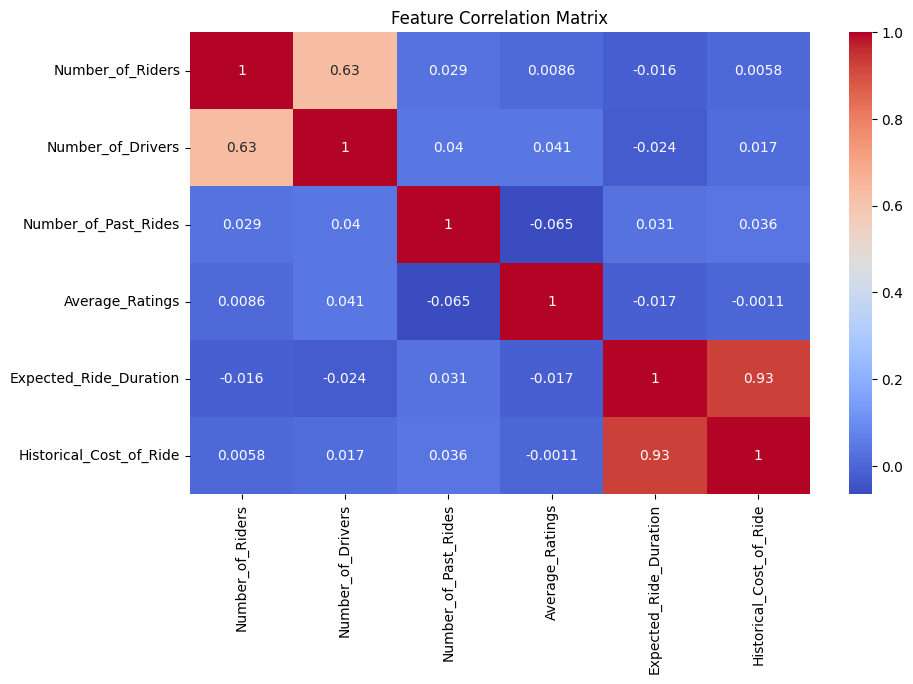

Number_of_Riders           0
Number_of_Drivers          0
Location_Category          0
Customer_Loyalty_Status    0
Number_of_Past_Rides       0
Average_Ratings            0
Time_of_Booking            0
Vehicle_Type               0
Expected_Ride_Duration     0
Historical_Cost_of_Ride    0
dtype: int64


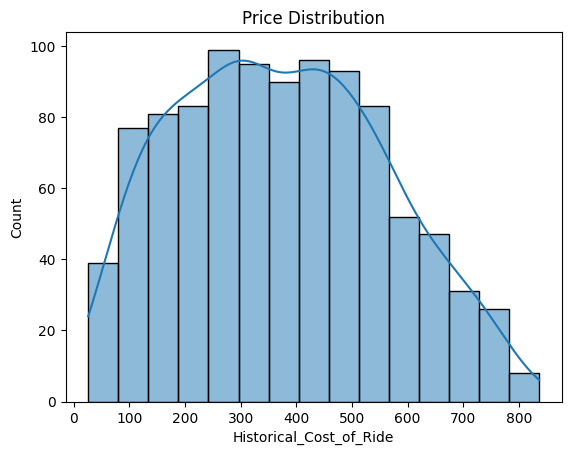

In [21]:
# Basic info
df.info()
df.describe()

# Visualize correlations
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

# Check for missing values
print(df.isnull().sum())

# Visualize target distribution
sns.histplot(df['Historical_Cost_of_Ride'], kde=True)
plt.title('Price Distribution')
plt.show()

## 4. Data Preprocessing

In [23]:
# Drop rows with missing target
df = df.dropna(subset=['Historical_Cost_of_Ride'])

# Fill missing values for other columns (simple strategy)
df = df.fillna(df.median(numeric_only=True))

# Encode categorical features
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'Historical_Cost_of_Ride']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Feature/target split
X = df_encoded.drop('Historical_Cost_of_Ride', axis=1)
y = df_encoded['Historical_Cost_of_Ride']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Train Three Regression Models

In [24]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Random Forest
rf = RandomForestRegressor(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

## 6. Model Evaluation

In [27]:
def regression_metrics(y_true, y_pred, name):
    print(f'\n{name} Results:')
    print(f'MAE: {mean_absolute_error(y_true, y_pred):.2f}')
    print(f'MSE: {mean_squared_error(y_true, y_pred):.2f}')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}')
    print(f'R2 Score: {r2_score(y_true, y_pred):.2f}')

regression_metrics(y_test, y_pred_lr, 'Linear Regression')
regression_metrics(y_test, y_pred_dt, 'Decision Tree')
regression_metrics(y_test, y_pred_rf, 'Random Forest')


Linear Regression Results:
MAE: 52.56
MSE: 4548.60
RMSE: 67.44
R2 Score: 0.88

Decision Tree Results:
MAE: 73.04
MSE: 9998.82
RMSE: 99.99
R2 Score: 0.73

Random Forest Results:
MAE: 55.07
MSE: 5389.81
RMSE: 73.42
R2 Score: 0.85


## 7. Feature Importance Analysis

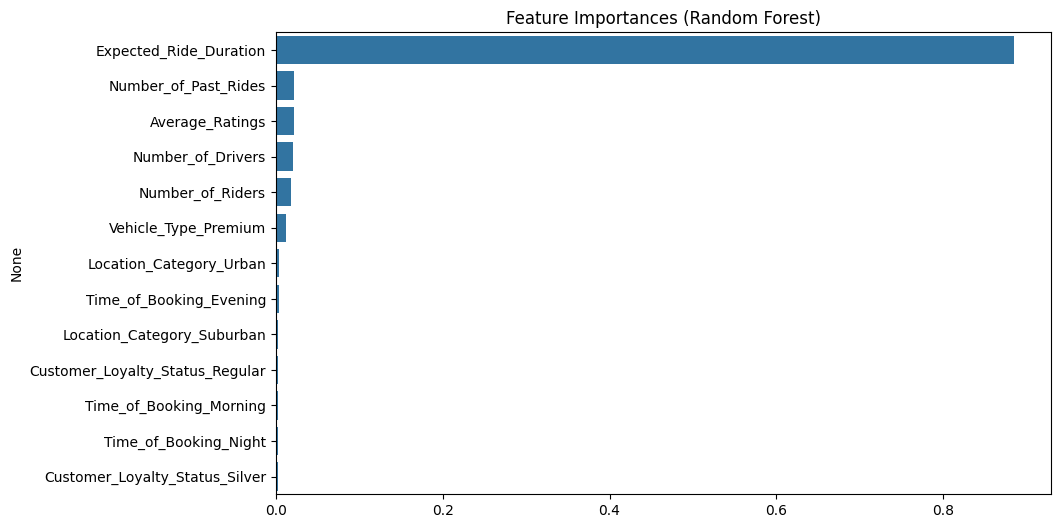

In [28]:
# Feature importances from Random Forest
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=features[indices])
plt.title('Feature Importances (Random Forest)')
plt.show()

## 8. Hyperparameter Tuning (Grid Search Example)

In [29]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)
print('Best parameters:', grid_search.best_params_)
print('Best R2 score:', grid_search.best_score_)

# Test best estimator
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
regression_metrics(y_test, y_pred_best_rf, 'Tuned Random Forest')

Best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Best R2 score: 0.8646044695986648

Tuned Random Forest Results:
MAE: 55.45
MSE: 5451.21
RMSE: 73.83
R2 Score: 0.85
